# F11 · Baselines y marco de evaluación

Este notebook establece las **líneas base de referencia** para la predicción horaria del precio eléctrico y define un marco homogéneo de evaluación para los modelos posteriores.

Se consideran cinco estrategias simples que utilizan únicamente información histórica del precio. Su objetivo no es maximizar la capacidad predictiva, sino proporcionar un umbral mínimo que cualquier modelo supervisado debería superar.

El análisis se apoya en dos criterios complementarios:

- **Calidad predictiva**, mediante MAE y RMSE.
- **Valor económico**, mediante una simulación simplificada de arbitraje con batería.

Los baselines se construyen directamente sobre `spot_price`, sin depender de `construir_dataset_maestro`. De este modo, permanecen desacoplados de cambios posteriores en las variables explicativas o en la estructura del dataset maestro.

No se utiliza MAPE porque la serie contiene precios nulos y negativos, lo que hace que las métricas porcentuales sean inestables o no estén definidas en parte del dominio.


## 0 · Preparación

Se cargan las dependencias, la configuración de acceso a PostgreSQL y los cortes temporales empleados en el resto del proyecto.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

sys.path.append(str(Path("../ingesta").resolve()))
from config import load_config

_, db = load_config()
engine = create_engine(
    "postgresql+psycopg2://",
    creator=lambda: psycopg2.connect(**db),
)

# Cortes temporales consistentes con construir_dataset_maestro.
TRAIN_END = pd.Timestamp("2024-12-31")
VAL_END = pd.Timestamp("2025-12-31")

print("Conexión a base de datos configurada.")


Conexión a base de datos configurada.


## 1 · Matriz diaria de precios

El precio horario se transforma en una matriz con **una fila por fecha y una columna por hora**. Esta representación funciona simultáneamente como variable objetivo y como fuente de información histórica para los baselines.

Se utiliza `es_esios` como serie de referencia. El calendario se regulariza a frecuencia diaria para garantizar que los desplazamientos temporales mediante `shift()` representen días naturales y no simplemente filas anteriores.


In [2]:
px = pd.read_sql(
    "SELECT datetime, es_esios "
    "FROM spot_price "
    "WHERE es_esios IS NOT NULL "
    "ORDER BY datetime",
    engine,
)

px["dt"] = pd.to_datetime(px["datetime"], utc=True).dt.tz_convert("Europe/Madrid")
px["fecha"] = pd.to_datetime(px["dt"].dt.date)
px["hora"] = px["dt"].dt.hour

P = px.pivot_table(
    index="fecha",
    columns="hora",
    values="es_esios",
    aggfunc="first",
)
P.columns = [f"h{h:02d}" for h in P.columns]

# Calendario continuo para que shift(N) represente exactamente N días naturales.
P = P.reindex(pd.date_range(P.index.min(), P.index.max(), freq="D"))
P.index.name = "fecha"

completos = P.notna().all(axis=1)

print(f"Días en el rango      : {len(P):,}".replace(",", "."))
print(f"Días completos (24 h) : {completos.sum():,}".replace(",", "."))
print(f"Días incompletos      : {(~completos).sum()}")
print(f"Periodo               : {P.index.min().date()} -> {P.index.max().date()}")

# Los días incompletos se conservan como historia, pero se excluyen de la evaluación.
P_eval = P[completos]


Días en el rango      : 2.430
Días completos (24 h) : 2.423
Días incompletos      : 7
Periodo               : 2020-01-01 -> 2026-08-26


## 2 · Definición de baselines

Todos los baselines generan una predicción de las 24 horas del día **D+1** utilizando exclusivamente información disponible antes de la fecha objetivo, de acuerdo con la frontera temporal definida para el proyecto.

| Baseline | Definición | Propósito |
|---|---|---|
| `persistencia_d1` | D+1 = D | Referencia de persistencia diaria |
| `persistencia_semanal` | D+1 = mismo día de la semana anterior | Captura estacionalidad semanal |
| `perfil_4_semanas` | Media de las últimas cuatro observaciones semanales equivalentes | Reduce variabilidad manteniendo el patrón semanal |
| `media_movil_7d` | Media de los últimos siete días, hora a hora | Referencia suavizada de corto plazo |
| `plano_d1` | Media del día D repetida en las 24 horas de D+1 | Separa el acierto del nivel diario del acierto de la forma intradiaria |

`plano_d1` tiene además una interpretación económica útil: al asignar el mismo precio previsto a todas las horas, elimina deliberadamente la información intradiaria y sirve como referencia para cuantificar cuánto aporta identificar correctamente las horas relativas de carga y descarga.


In [3]:
def construir_baselines(P: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Construye predicciones baseline indexadas por la fecha objetivo."""
    baselines = {
        "persistencia_d1": P.shift(1),
        "persistencia_semanal": P.shift(7),
        "perfil_4_semanas": (
            P.shift(7) + P.shift(14) + P.shift(21) + P.shift(28)
        ) / 4,
        "media_movil_7d": P.shift(1).rolling(7, min_periods=4).mean(),
    }

    media_dia_anterior = P.shift(1).mean(axis=1)
    baselines["plano_d1"] = pd.DataFrame(
        {col: media_dia_anterior for col in P.columns},
        index=P.index,
    )

    return baselines


BASELINES = construir_baselines(P)

for nombre, pred in BASELINES.items():
    primera_fecha = pred.dropna().index.min().date()
    print(f"{nombre:<22} primera fecha disponible: {primera_fecha}")


persistencia_d1        primera fecha disponible: 2020-01-02
persistencia_semanal   primera fecha disponible: 2020-01-08
perfil_4_semanas       primera fecha disponible: 2020-01-29
media_movil_7d         primera fecha disponible: 2020-01-05
plano_d1               primera fecha disponible: 2020-01-02


### 2.1 · Verificación temporal

Como control básico frente a posibles fugas de información, se compara el error de cada baseline sobre su fecha objetivo correcta con el error obtenido al desplazar el objetivo un día.

Dada la autocorrelación diaria del precio eléctrico, una predicción correctamente alineada debería mostrar un rendimiento superior sobre la fecha que realmente le corresponde. Esta prueba es un control de coherencia y no sustituye una auditoría completa de disponibilidad temporal de variables.


In [4]:
def mae(pred: pd.DataFrame, real: pd.DataFrame) -> float:
    comun = pred.index.intersection(real.index)
    error = pred.loc[comun] - real.loc[comun]
    return float(error.abs().stack().mean())


print("CONTROL DE ALINEACIÓN TEMPORAL\n")

real_desplazado = P_eval.shift(-1).dropna()

for nombre, pred in BASELINES.items():
    error_correcto = mae(pred, P_eval)
    error_desplazado = mae(pred, real_desplazado)
    mejora = 100 * (error_desplazado - error_correcto) / error_desplazado
    estado = "OK" if mejora > 1 else "REVISAR"

    print(
        f"{nombre:<22} correcto={error_correcto:6.2f}  "
        f"desplazado={error_desplazado:6.2f}  "
        f"diferencia={mejora:+5.1f}%  {estado}"
    )

print(
    "\nNota: 'plano_d1' puede mostrar una diferencia menor porque utiliza "
    "únicamente el nivel medio del día anterior y no su perfil horario."
)


CONTROL DE ALINEACIÓN TEMPORAL

persistencia_d1        correcto= 17.92  desplazado= 23.83  diferencia=+24.8%  OK
persistencia_semanal   correcto= 26.19  desplazado= 28.57  diferencia= +8.3%  OK
perfil_4_semanas       correcto= 25.25  desplazado= 27.23  diferencia= +7.3%  OK
media_movil_7d         correcto= 20.57  desplazado= 22.18  diferencia= +7.2%  OK
plano_d1               correcto= 23.88  desplazado= 28.09  diferencia=+15.0%  OK

Nota: 'plano_d1' puede mostrar una diferencia menor porque utiliza únicamente el nivel medio del día anterior y no su perfil horario.


## 3 · Métricas de error

La evaluación predictiva utiliza:

- **MAE (€/MWh):** error absoluto medio.
- **RMSE (€/MWh):** penaliza con mayor intensidad los errores extremos.
- **Sesgo (€/MWh):** permite detectar desviaciones sistemáticas de sobreestimación o subestimación.

Las métricas se calculan por tramo temporal (`train`, `val`, `test`) y, adicionalmente, por hora del día en validación.


In [5]:
def tramo(idx: pd.DatetimeIndex) -> pd.Series:
    etiquetas = np.select(
        [idx <= TRAIN_END, idx <= VAL_END],
        ["train", "val"],
        default="test",
    )
    return pd.Series(etiquetas, index=idx)


def errores(pred: pd.DataFrame, real: pd.DataFrame) -> pd.DataFrame:
    comun = pred.dropna(how="all").index.intersection(real.index)
    diferencia = pred.loc[comun] - real.loc[comun]
    etiquetas = tramo(comun)

    filas = []
    for nombre_tramo in ["train", "val", "test"]:
        sub = diferencia[etiquetas == nombre_tramo]
        if sub.empty:
            continue

        valores = sub.stack()
        filas.append(
            {
                "tramo": nombre_tramo,
                "dias": len(sub),
                "MAE": valores.abs().mean(),
                "RMSE": np.sqrt((valores**2).mean()),
                "sesgo": valores.mean(),
            }
        )

    return pd.DataFrame(filas).set_index("tramo")


resumen = {}
for nombre, pred in BASELINES.items():
    metricas = errores(pred, P_eval)
    for nombre_tramo in metricas.index:
        resumen[(nombre, nombre_tramo)] = metricas.loc[nombre_tramo]

ERRORES = pd.DataFrame(resumen).T.round(2)
ERRORES.index.names = ["baseline", "tramo"]

print("ERROR DE LOS BASELINES (EUR/MWh)\n")
print(ERRORES.to_string())
print("\nObjetivo de referencia del proyecto: MAE < 8 y RMSE < 12.")


ERROR DE LOS BASELINES (EUR/MWh)

                              dias    MAE   RMSE  sesgo
baseline             tramo                             
persistencia_d1      train  1821.0  17.61  28.68  -0.08
                     val     364.0  19.94  28.87   0.10
                     test    237.0  17.21  26.42  -0.07
persistencia_semanal train  1815.0  25.63  41.01  -0.38
                     val     364.0  28.99  40.57   0.81
                     test    237.0  26.23  38.13  -0.81
perfil_4_semanas     train  1794.0  24.70  37.65  -0.76
                     val     364.0  26.24  34.63   1.40
                     test    237.0  27.90  36.76  -3.03
media_movil_7d       train  1818.0  20.04  30.84  -0.27
                     val     364.0  23.26  30.75   0.40
                     test    237.0  20.50  28.69  -0.34
plano_d1             train  1821.0  20.89  31.45  -0.08
                     val     364.0  30.20  38.79   0.10
                     test    237.0  37.15  46.89  -0.07

Objetivo de r

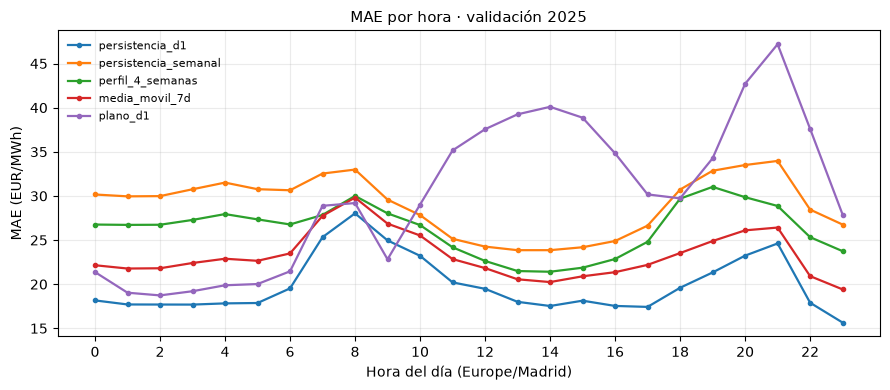

     persistencia_d1  persistencia_semanal  perfil_4_semanas  media_movil_7d  plano_d1
h00            18.16                 30.16             26.76           22.15     21.37
h01            17.70                 29.95             26.72           21.77     19.04
h02            17.69                 29.98             26.73           21.80     18.73
h03            17.69                 30.76             27.28           22.40     19.20
h04            17.83                 31.51             27.94           22.88     19.88
h05            17.87                 30.76             27.34           22.65     20.02
h06            19.52                 30.64             26.77           23.49     21.46
h07            25.33                 32.54             27.85           27.74     28.88
h08            28.03                 32.99             30.00           29.81     29.19
h09            24.96                 29.58             28.02           26.86     22.82
h10            23.22                 27.83 

In [6]:
# Error horario en el conjunto de validación (2025).
val = P_eval[(P_eval.index > TRAIN_END) & (P_eval.index <= VAL_END)]

por_hora = pd.DataFrame(
    {
        nombre: (
            pred.loc[pred.index.intersection(val.index)] - val
        ).abs().mean()
        for nombre, pred in BASELINES.items()
    }
)

fig, ax = plt.subplots(figsize=(9, 4))
for col in por_hora.columns:
    ax.plot(
        range(24),
        por_hora[col],
        marker="o",
        markersize=3,
        lw=1.6,
        label=col,
    )

ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hora del día (Europe/Madrid)")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_title("MAE por hora · validación 2025", fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(por_hora.round(2).to_string())


## 4 · Evaluación económica

El error estadístico no necesariamente refleja el impacto operativo de una predicción. Para incorporar esa dimensión se simula una estrategia simplificada de arbitraje con batería.

Para cada día, la estrategia:

1. carga durante las `k` horas con menor precio **previsto**;
2. descarga durante las `k` horas con mayor precio **previsto**;
3. liquida ambas operaciones utilizando los precios **reales**.

El resultado se compara con una estrategia de **previsión perfecta**, que selecciona las horas con conocimiento de los precios reales. La métrica `capturado_%` expresa qué proporción del beneficio teórico máximo obtiene cada baseline bajo estas hipótesis.


In [7]:
def ingreso_arbitraje(
    pred: pd.DataFrame,
    real: pd.DataFrame,
    k: int = 4,
    eficiencia: float = 0.85,
) -> pd.Series:
    """Calcula el ingreso diario de arbitraje para una batería de 1 MW / k MWh.

    La selección de horas se realiza sobre la predicción y la liquidación sobre
    el precio real. La eficiencia de ciclo se aplica a la energía descargada.
    """
    comun = pred.dropna(how="all").index.intersection(real.index)
    p = pred.loc[comun].to_numpy()
    r = real.loc[comun].to_numpy()

    orden = np.argsort(p, axis=1)
    horas_carga = orden[:, :k]
    horas_descarga = orden[:, -k:]

    coste = np.take_along_axis(r, horas_carga, axis=1).sum(axis=1)
    ingreso = (
        np.take_along_axis(r, horas_descarga, axis=1).sum(axis=1)
        * eficiencia
    )

    return pd.Series(ingreso - coste, index=comun, name="ingreso")


def evaluar_dinero(
    pred: pd.DataFrame,
    real: pd.DataFrame,
    k: int = 4,
    eficiencia: float = 0.85,
) -> pd.DataFrame:
    ingreso = ingreso_arbitraje(pred, real, k, eficiencia)
    perfecto = ingreso_arbitraje(real, real, k, eficiencia)

    comun = ingreso.index.intersection(perfecto.index)
    ingreso = ingreso.loc[comun]
    perfecto = perfecto.loc[comun]
    etiquetas = tramo(comun)

    filas = []
    for nombre_tramo in ["train", "val", "test"]:
        mascara = etiquetas == nombre_tramo
        if not mascara.any():
            continue

        filas.append(
            {
                "tramo": nombre_tramo,
                "dias": int(mascara.sum()),
                "ingreso_dia": ingreso[mascara].mean(),
                "techo_dia": perfecto[mascara].mean(),
                "capturado_%": 100
                * ingreso[mascara].sum()
                / perfecto[mascara].sum(),
                "dias_en_perdida_%": 100 * (ingreso[mascara] < 0).mean(),
            }
        )

    return pd.DataFrame(filas).set_index("tramo")


DINERO = pd.concat(
    {
        nombre: evaluar_dinero(pred, P_eval)
        for nombre, pred in BASELINES.items()
    }
)
DINERO.index.names = ["baseline", "tramo"]

print("INGRESO DE ARBITRAJE · batería 1 MW / 4 MWh · eficiencia 85%\n")
print(DINERO.round(2).to_string())
print(
    "\n'capturado_%' representa la proporción del beneficio máximo teórico "
    "obtenida por cada estrategia."
)


INGRESO DE ARBITRAJE · batería 1 MW / 4 MWh · eficiencia 85%

                            dias  ingreso_dia  techo_dia  capturado_%  dias_en_perdida_%
baseline             tramo                                                              
persistencia_d1      train  1821        92.18     134.53        68.52              15.10
                     val     364       232.08     268.19        86.54               1.65
                     test    237       306.25     334.96        91.43               0.00
persistencia_semanal train  1815        97.65     134.84        72.42              12.95
                     val     364       231.37     268.19        86.27               0.00
                     test    237       306.29     334.96        91.44               0.84
perfil_4_semanas     train  1794       106.75     135.92        78.54              10.26
                     val     364       239.24     268.19        89.21               0.82
                     test    237       313.63   

### 4.1 · Relación entre error predictivo y valor económico

Se compara el ranking de los baselines según MAE con el ranking según porcentaje de beneficio capturado. Si ambos rankings difieren, el MAE no puede utilizarse como sustituto directo del valor económico para seleccionar el modelo final.


In [8]:
comparacion = pd.DataFrame(
    {
        "MAE_val": ERRORES.xs("val", level="tramo")["MAE"],
        "capturado_val_%": DINERO.xs("val", level="tramo")["capturado_%"],
    }
).round(2)

comparacion["puesto_MAE"] = comparacion["MAE_val"].rank().astype(int)
comparacion["puesto_dinero"] = (
    comparacion["capturado_val_%"].rank(ascending=False).astype(int)
)
comparacion["coinciden"] = np.where(
    comparacion["puesto_MAE"] == comparacion["puesto_dinero"],
    "sí",
    "no",
)

print(comparacion.sort_values("puesto_MAE").to_string())

if (comparacion["coinciden"] == "no").any():
    print(
        "\nConclusión: los criterios no generan el mismo ranking. "
        "El error medio y el valor económico deben evaluarse por separado."
    )
else:
    print(
        "\nConclusión: ambos criterios coinciden para estos baselines. "
        "La comparación deberá repetirse con los modelos supervisados."
    )


                      MAE_val  capturado_val_%  puesto_MAE  puesto_dinero coinciden
baseline                                                                           
persistencia_d1         19.94            86.54           1              3        no
media_movil_7d          23.26            91.16           2              1        no
perfil_4_semanas        26.24            89.21           3              2        no
persistencia_semanal    28.99            86.27           4              4        sí
plano_d1                30.20           -40.65           5              5        sí

Conclusión: los criterios no generan el mismo ranking. El error medio y el valor económico deben evaluarse por separado.


## 5 · Evaluación en días de mayor diferencial

El valor económico del arbitraje se concentra especialmente en jornadas con una diferencia elevada entre el precio máximo y mínimo del día. Para comprobar la robustez de los baselines en ese contexto, se repite la evaluación sobre el **20 % de días con mayor diferencial real** del conjunto de validación.


In [9]:
spread_real = P_eval.max(axis=1) - P_eval.min(axis=1)
val_idx = spread_real[
    (spread_real.index > TRAIN_END) & (spread_real.index <= VAL_END)
]

umbral = val_idx.quantile(0.80)
dias_top = val_idx[val_idx >= umbral].index

print(
    f"Días del quintil superior en 2025: {len(dias_top)} "
    f"(diferencial >= {umbral:.1f} EUR/MWh)\n"
)

filas = []
for nombre, pred in BASELINES.items():
    sub_pred = pred.loc[pred.index.intersection(dias_top)]
    sub_real = P_eval.loc[dias_top]
    comun = sub_pred.index.intersection(sub_real.index)

    ingreso = ingreso_arbitraje(sub_pred.loc[comun], sub_real.loc[comun])
    perfecto = ingreso_arbitraje(sub_real.loc[comun], sub_real.loc[comun])

    filas.append(
        {
            "baseline": nombre,
            "MAE": float(
                (sub_pred.loc[comun] - sub_real.loc[comun]).abs().stack().mean()
            ),
            "ingreso_dia": ingreso.mean(),
            "techo_dia": perfecto.mean(),
            "capturado_%": 100 * ingreso.sum() / perfecto.sum(),
        }
    )

TOP = pd.DataFrame(filas).set_index("baseline").round(2)

print("DÍAS DE MAYOR DIFERENCIAL · validación 2025")
print(TOP.to_string())
print(
    "\nLa comparación con la evaluación global permite identificar si el "
    "rendimiento se deteriora precisamente en los días de mayor valor económico."
)


Días del quintil superior en 2025: 73 (diferencial >= 130.3 EUR/MWh)

DÍAS DE MAYOR DIFERENCIAL · validación 2025
                        MAE  ingreso_dia  techo_dia  capturado_%
baseline                                                        
persistencia_d1       24.08       377.22     410.05        92.00
persistencia_semanal  30.04       360.08     410.05        87.81
perfil_4_semanas      28.39       368.06     410.05        89.76
media_movil_7d        24.65       389.48     410.05        94.98
plano_d1              42.19      -148.73     410.05       -36.27

La comparación con la evaluación global permite identificar si el rendimiento se deteriora precisamente en los días de mayor valor económico.


## 6 · Resumen de referencia

Se identifican los mejores baselines según MAE y según beneficio capturado en validación. Estas cifras constituyen el punto de comparación para los modelos posteriores.


In [10]:
mejor_error = ERRORES.xs("val", level="tramo")["MAE"].idxmin()
mejor_dinero = DINERO.xs("val", level="tramo")["capturado_%"].idxmax()

print("=" * 74)
print("REFERENCIA A SUPERAR · validación 2025")
print("=" * 74)

print(f"\nMejor baseline por error: {mejor_error}")
print(
    f"  MAE  = {ERRORES.loc[(mejor_error, 'val'), 'MAE']:.2f} EUR/MWh\n"
    f"  RMSE = {ERRORES.loc[(mejor_error, 'val'), 'RMSE']:.2f} EUR/MWh"
)

print(f"\nMejor baseline por valor económico: {mejor_dinero}")
print(
    f"  Beneficio capturado = "
    f"{DINERO.loc[(mejor_dinero, 'val'), 'capturado_%']:.1f}%\n"
    f"  Ingreso medio       = "
    f"{DINERO.loc[(mejor_dinero, 'val'), 'ingreso_dia']:.2f} EUR/día\n"
    f"  Techo teórico       = "
    f"{DINERO.loc[(mejor_dinero, 'val'), 'techo_dia']:.2f} EUR/día"
)

print(
    "\nCriterios para los modelos posteriores:\n"
    "1. Comparar cada modelo con el mejor baseline, no únicamente con objetivos absolutos.\n"
    "2. Evaluar por separado precisión predictiva y valor económico.\n"
    "3. Revisar la adecuación del objetivo MAE < 8 a la dificultad observada en los baselines.\n"
    "4. Utilizar persistencia_d1 como referencia naive para el análisis de ingreso incremental."
)

# Salidas regenerables: no es necesario versionarlas si data_temp está en .gitignore.
SALIDA = Path("../data_temp")
SALIDA.mkdir(exist_ok=True)

ERRORES.to_csv(SALIDA / "baselines_errores.csv")
DINERO.to_csv(SALIDA / "baselines_dinero.csv")

print(f"\nResultados guardados en {SALIDA.resolve()}:")
print("  - baselines_errores.csv")
print("  - baselines_dinero.csv")


REFERENCIA A SUPERAR · validación 2025

Mejor baseline por error: persistencia_d1
  MAE  = 19.94 EUR/MWh
  RMSE = 28.87 EUR/MWh

Mejor baseline por valor económico: media_movil_7d
  Beneficio capturado = 91.2%
  Ingreso medio       = 244.49 EUR/día
  Techo teórico       = 268.19 EUR/día

Criterios para los modelos posteriores:
1. Comparar cada modelo con el mejor baseline, no únicamente con objetivos absolutos.
2. Evaluar por separado precisión predictiva y valor económico.
3. Revisar la adecuación del objetivo MAE < 8 a la dificultad observada en los baselines.
4. Utilizar persistencia_d1 como referencia naive para el análisis de ingreso incremental.

Resultados guardados en /Users/magui/git/edev_models/data_temp:
  - baselines_errores.csv
  - baselines_dinero.csv


## 7 · Visualizaciones

Se generan tres gráficos orientados a comunicación de resultados: comparación de MAE, porcentaje de beneficio capturado e ingreso acumulado durante el periodo de validación.


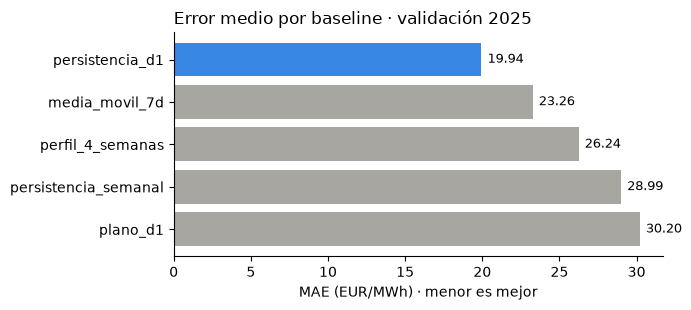

In [11]:
mae_val = ERRORES.xs("val", level="tramo")["MAE"].sort_values()
colores = ["#3987e5"] + ["#a8a6a0"] * (len(mae_val) - 1)

fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh(mae_val.index, mae_val.values, color=colores)
ax.invert_yaxis()
ax.set_xlabel("MAE (EUR/MWh) · menor es mejor")
ax.set_title("Error medio por baseline · validación 2025", loc="left")

for barra, valor in zip(barras, mae_val.values):
    ax.text(
        valor + 0.4,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}",
        va="center",
        fontsize=9,
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../data_temp/baseline_mae.png", dpi=150, facecolor="white")
plt.show()


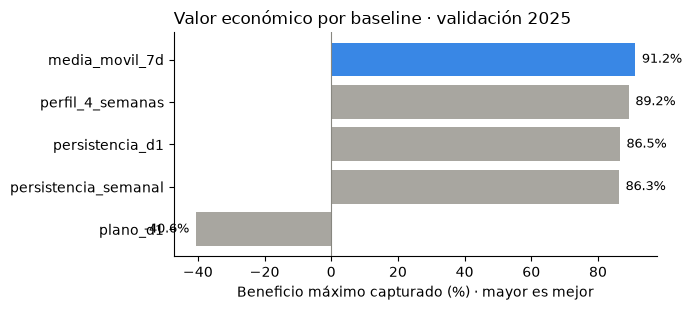

In [12]:
din_val = (
    DINERO.xs("val", level="tramo")["capturado_%"]
    .sort_values(ascending=False)
)
colores = ["#3987e5"] + ["#a8a6a0"] * (len(din_val) - 1)

fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh(din_val.index, din_val.values, color=colores)
ax.invert_yaxis()
ax.axvline(0, color="#888780", linewidth=0.8)
ax.set_xlabel("Beneficio máximo capturado (%) · mayor es mejor")
ax.set_title("Valor económico por baseline · validación 2025", loc="left")

for barra, valor in zip(barras, din_val.values):
    offset = 2 if valor >= 0 else -2
    ha = "left" if valor >= 0 else "right"
    ax.text(
        valor + offset,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        va="center",
        ha=ha,
        fontsize=9,
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../data_temp/baseline_dinero.png", dpi=150, facecolor="white")
plt.show()


### 7.1 · Ingreso acumulado

El ingreso acumulado complementa las métricas agregadas y permite observar si la ventaja de una estrategia es estable a lo largo del año o depende de un número reducido de jornadas.


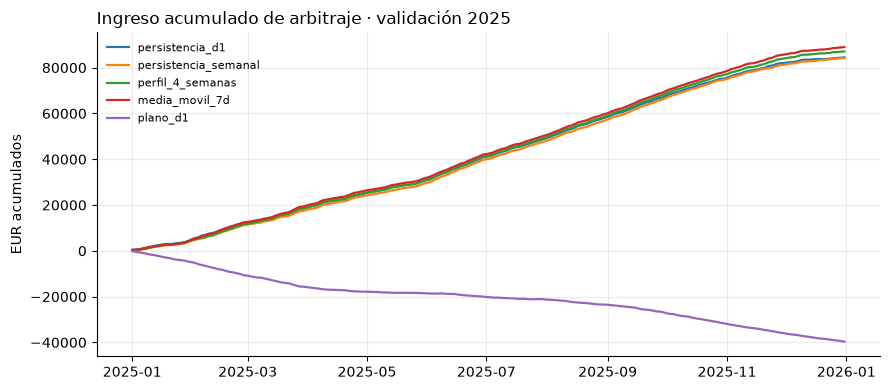

Gráficos guardados en data_temp/: baseline_mae.png, baseline_dinero.png y baseline_ingreso_acumulado.png


In [13]:
val_idx = P_eval.index[
    (P_eval.index > TRAIN_END) & (P_eval.index <= VAL_END)
]

fig, ax = plt.subplots(figsize=(9, 4))

for nombre, pred in BASELINES.items():
    ingreso = ingreso_arbitraje(pred, P_eval)
    ingreso_val = ingreso.loc[ingreso.index.intersection(val_idx)].sort_index()
    ax.plot(
        ingreso_val.index,
        ingreso_val.cumsum(),
        label=nombre,
        lw=1.6,
    )

ax.set_title("Ingreso acumulado de arbitraje · validación 2025", loc="left")
ax.set_ylabel("EUR acumulados")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(
    "../data_temp/baseline_ingreso_acumulado.png",
    dpi=150,
    facecolor="white",
)
plt.show()

print(
    "Gráficos guardados en data_temp/: baseline_mae.png, "
    "baseline_dinero.png y baseline_ingreso_acumulado.png"
)
